# 06 – Detektor Összehasonlítás: GEOMETRIC_RULE vs. INTENSITY_DATA

Ez a notebook vizuálisan összehasonlítja a két bund-detektáló algoritmust
5 véletlenszerűen kiválasztott **teszt képen**.

| Oszlop | Tartalom |
|---|---|
| **1** | Eredeti kép + MediaPipe ujjak |
| **2** | `GEOMETRIC_RULE` – Hough-alapú bund-illesztés |
| **3** | `INTENSITY_DATA` – Sobel-X gradiens csúcsdetektálás |

**Fontos:** Ez a notebook **kizárólag `src/` modulokat** importál.
Sem függvényt, sem osztályt nem definiál – minden logika az `src/` csomagban él.

In [1]:
%matplotlib inline
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Kizárólag src/ modulok ──────────────────────────────────────────────────
from src.config import CFG, PATHS
from src.fretboard import run_v14_pipeline, GeometricFretDetector, IntensityFretDetector
from src.viz import PipelineVisualizer

plt.rcParams['figure.dpi'] = 96
plt.rcParams['savefig.dpi'] = 120
plt.rcParams['image.interpolation'] = 'bilinear'

print('Modulok betöltve.')

Modulok betöltve.


## 1. Képek kiválasztása – teszt split

5 kép az összes osztályból egyenletesen elosztva (`random_state=42`).

> **Megjegyzés:** A teszt split-et ebben a notebookban kizárólag vizuális
> algoritmikus összehasonlításra használjuk – nem modellválasztásra.
> A végső modell-kiértékelés (accuracy, F1) a `06_evaluation.ipynb`-ben történik.

In [2]:
N_IMAGES = 5

manifest = pd.read_csv(PATHS['manifest'])
test_df  = manifest[manifest['split'] == 'test'].copy()

chosen = (
    test_df
    .sort_values('class')
    .groupby('class', group_keys=False)
    .apply(lambda g: g.sample(1, random_state=CFG['random_seed']))
    .sample(frac=1, random_state=CFG['random_seed'])   # osztályok véletlenszerű sorrendje
    .reset_index(drop=True)
    .head(N_IMAGES)
)

print(f'{len(chosen)} kép kiválasztva a teszt splitből:')
print(chosen[['class', 'filename']].to_string(index=False))

5 kép kiválasztva a teszt splitből:
  class                filename
      B       1762212364116.jpg
      F IMG_20251102_023927.jpg
      A       1762212326260.jpg
No hand IMG_20251102_023831.jpg
      C       1762212395050.jpg


## 2. Pipeline futtatás mindkét detektorral

Minden képre kétszer futtatjuk a `run_v14_pipeline`-t:
- `GeometricFretDetector()` – az eredeti Hough-alapú módszer
- `IntensityFretDetector()` – Sobel-X gradiens + `find_peaks`

A két futtatás **nem osztja meg az állapotot** – mindkét detektor önálló példány.

In [3]:
geo_detector = GeometricFretDetector()
int_detector = IntensityFretDetector()

pipeline_pairs = []   # list of (result_geo, result_int)

print(f"{'Fájl':<35} {'Cls':>4}  {'geo_ok':>6}  {'int_ok':>6}  "
      f"{'geo_cov':>8}  {'int_cov':>8}  {'geo_n':>6}  {'int_n':>6}")
print('-' * 90)

for _, row in chosen.iterrows():
    entry = {'path': row['path'], 'class': row['class'], 'filename': row['filename']}

    r_geo = run_v14_pipeline(entry, fret_detector=geo_detector)
    r_int = run_v14_pipeline(entry, fret_detector=int_detector)
    pipeline_pairs.append((r_geo, r_int))

    geo_cov = r_geo.get('fit', {}).get('coverage_ratio', 0.0) or 0.0
    int_cov = r_int.get('fit', {}).get('coverage_ratio', 0.0) or 0.0
    geo_n   = len(r_geo.get('fret_xs_raw') or [])
    int_n   = len(r_int.get('fret_xs_raw') or [])

    print(f"{row['filename']:<35} {row['class']:>4}  "
          f"{'✓' if r_geo['ok'] else '✗':>6}  {'✓' if r_int['ok'] else '✗':>6}  "
          f"{geo_cov:>8.3f}  {int_cov:>8.3f}  {geo_n:>6}  {int_n:>6}")

Fájl                                 Cls  geo_ok  int_ok   geo_cov   int_cov   geo_n   int_n
------------------------------------------------------------------------------------------


I0000 00:00:1779214618.308754 1065276 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1779214618.313909 1065290 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-2), renderer: Mesa Intel(R) Iris(R) Xe Graphics (TGL GT2)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1779214618.330784 1065278 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1779214618.346242 1065284 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1779214618.681174 1065284 landmark_projection_calculator.cc:78] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


  [outer_edges_v9] vonalak: 17 | bal outlier: igen | jobb outlier: nem
  [outer_edges_v9] Jobb oldal bővítve: +108.6px
  [outer_edges_v9] szétválasztás: 499.5px (klaszter: 362.0px | bővítés: 108.6px)
  [extend_amin] a_min 2496.5 → 1917.9 (landmark_min=1957.9, margin=40px)
  [trapezoid_v9] span=3023.3px | w_start=499.5px | w_end=499.5px | area=1570648px²
  [nut_detect_v12] side_hint=left | median=1077 | peak=15916 | ratio=14.78 | fwhm=6.0px
  [nut_detect_v12] nut találat: left @ x=183px (fwhm=6.0px)
  [step7] Hough: 117 nyers vonal → szűrve: 19
  [step7] HoughLinesP → 10 klaszter (0 széles kizárva)
  [fret_fit v11] nut-anchored | scale=2271.3px | cov=83% (5/6)
  [fret_fit v11] nut-anchored | scale=2271.3px | cov=83% (5/6)
  [outer_edges_v9] vonalak: 17 | bal outlier: igen | jobb outlier: nem
  [outer_edges_v9] Jobb oldal bővítve: +108.6px
  [outer_edges_v9] szétválasztás: 499.5px (klaszter: 362.0px | bővítés: 108.6px)
  [extend_amin] a_min 2496.5 → 1917.9 (landmark_min=1957.9, margin=40

## 3. Vizualizátor példányosítása

`PipelineVisualizer` minden paramétere explicit, globális állapot nélkül.

In [4]:
viz = PipelineVisualizer(
    neck_color       = (50, 220, 50),    # zöld – gitárnyak trapéz
    fret_color       = (80, 80, 240),    # kék – visszavetített bundvonalak
    landmark_color   = (0, 230, 230),    # cián – landmark pontok
    connection_color = (230, 160, 0),    # narancssárga – ujjcsontváz
    fingertip_color  = (0, 180, 255),    # világoskék – ujjhegyek
    point_radius     = 5,
    font_scale       = 0.50,
)

## 4. Összehasonlítás Dashboard

Képenként 3-oszlopos nézet a `draw_3panel_comparison` metódussal.

A cím sorban látható:
- **ok** – a pipeline sikeresen futott-e
- **cov** – `coverage_ratio`: a 17.817-es szabály szerint illesztett bundok
  aránya a detektált csúcsokhoz képest
- **raw_n** – a detektáló által visszaadott nyers csúcsok száma (szűrés előtt)

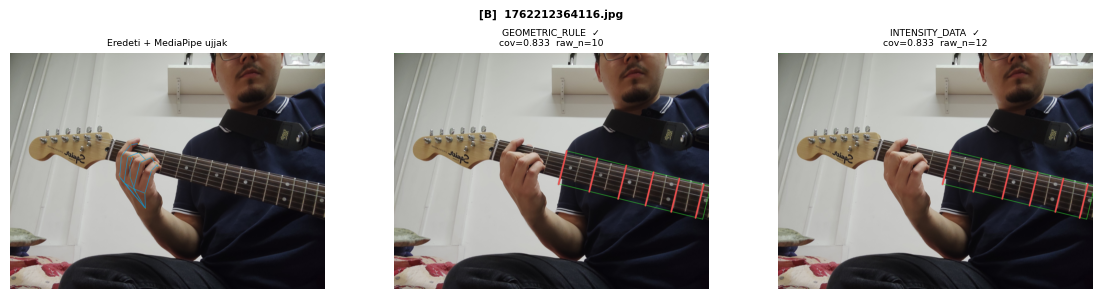

Mentve: ../output/06_comparison_dashboard/comparison_00_1762212364116.jpg.png


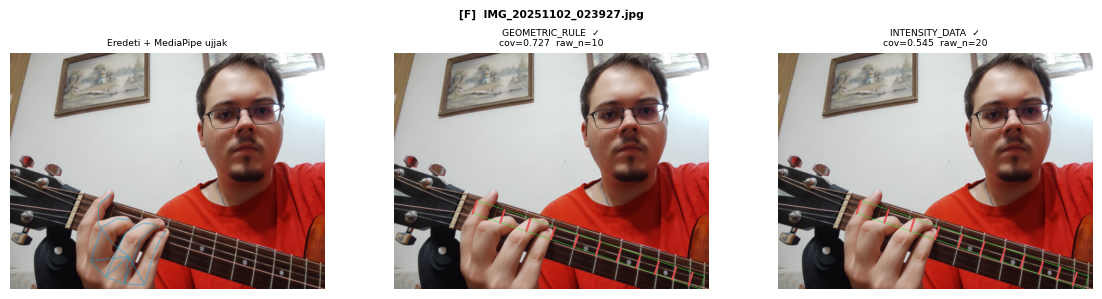

Mentve: ../output/06_comparison_dashboard/comparison_01_IMG_20251102_023927.jpg.png


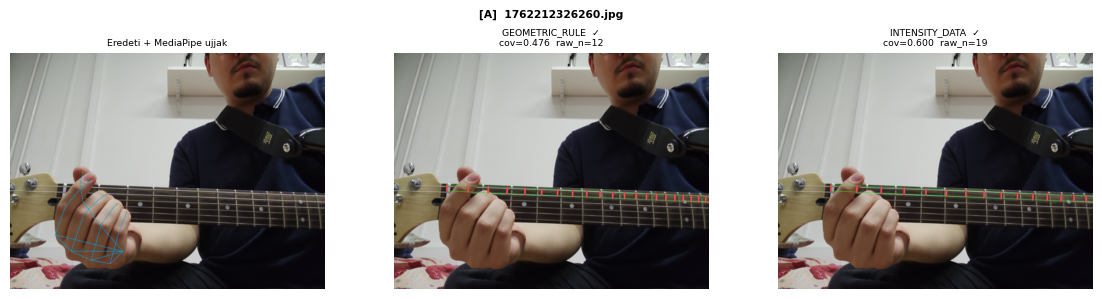

Mentve: ../output/06_comparison_dashboard/comparison_02_1762212326260.jpg.png


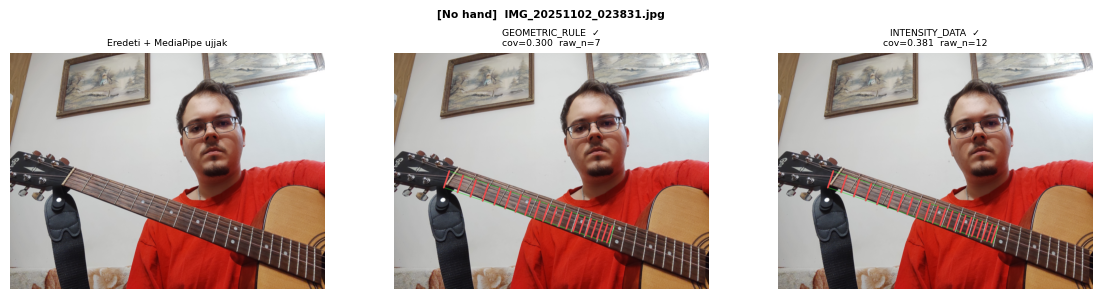

Mentve: ../output/06_comparison_dashboard/comparison_03_IMG_20251102_023831.jpg.png


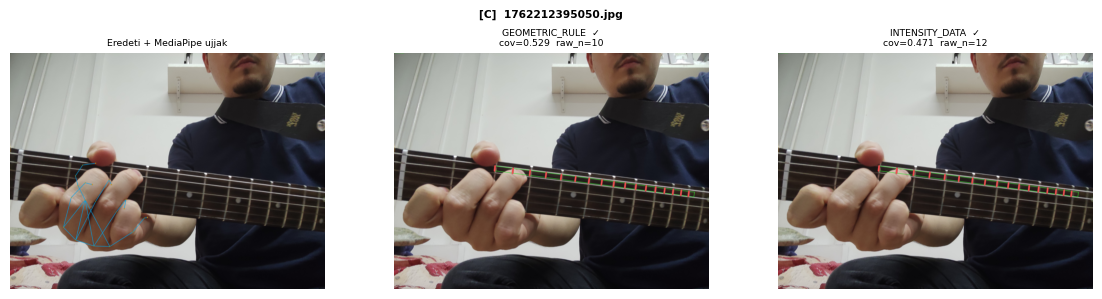

Mentve: ../output/06_comparison_dashboard/comparison_04_1762212395050.jpg.png


In [5]:
import cv2
from pathlib import Path

OUTPUT_DIR = Path('..') / 'output' / '06_comparison_dashboard'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for i, (r_geo, r_int) in enumerate(pipeline_pairs):
    img_path = r_geo.get('path') or r_int.get('path')
    image    = cv2.imread(str(img_path))
    if image is None:
        print(f'[WARN] Kép nem olvasható: {img_path}')
        continue

    fname     = r_geo.get('fname', r_geo.get('filename', Path(img_path).name))
    save_path = OUTPUT_DIR / f'comparison_{i:02d}_{fname}.png'

    fig = viz.draw_3panel_comparison(
        image,
        result_geo=r_geo,
        result_int=r_int,
        figsize=(18, 6),
        save_path=save_path,
    )
    print(f'Mentve: {save_path}')
    plt.close(fig)

## 5. Teljes 2×3-as összehasonlítás (kanonikus tér + gradiens profil)

OK-státuszú képekhez a `draw_detector_comparison` részletesebb nézetet ad:
- Sor 1: overlay visszavetítve + diff (csak-geo = kék, csak-int = narancs, közös = zöld)
- Sor 2: kanonikus 600×80 nézet + intenzitás gradiens-profil

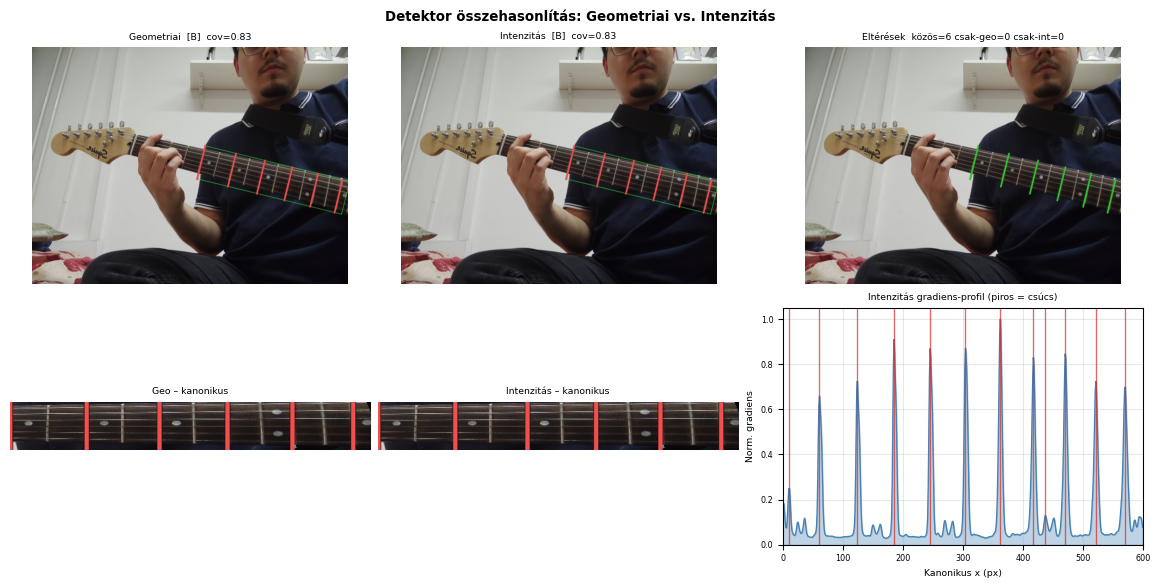

Mentve: ../output/06_comparison_dashboard/detailed_00_1762212364116.jpg.png


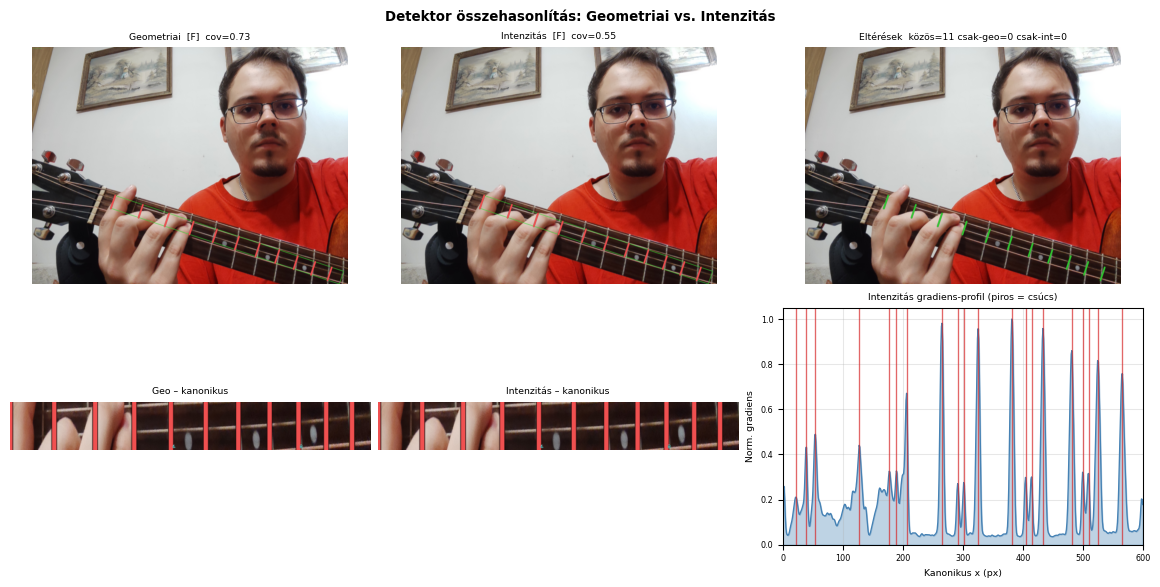

Mentve: ../output/06_comparison_dashboard/detailed_01_IMG_20251102_023927.jpg.png


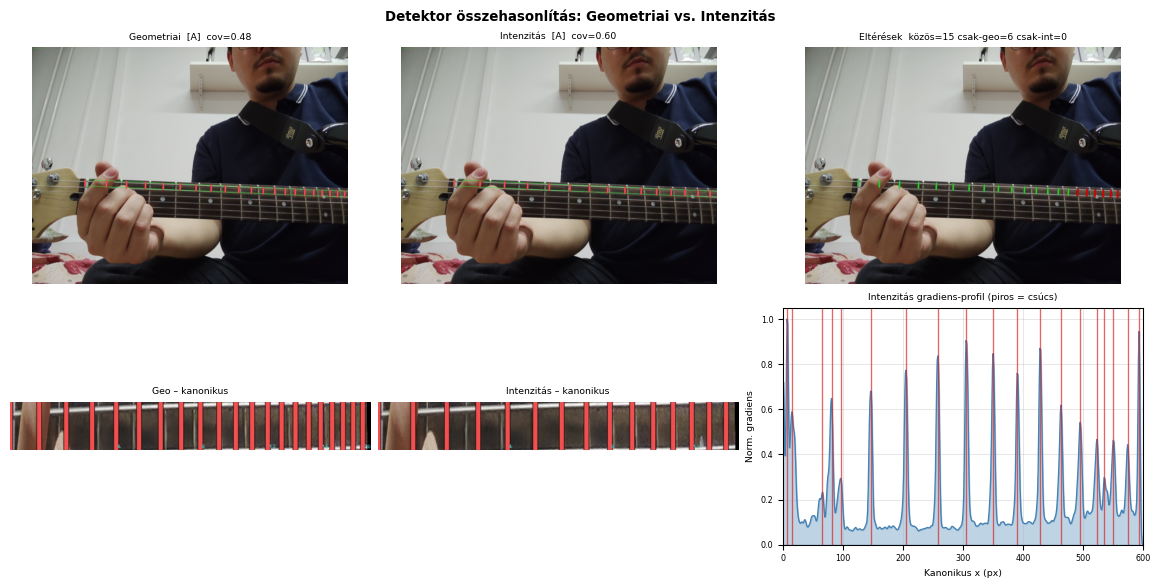

Mentve: ../output/06_comparison_dashboard/detailed_02_1762212326260.jpg.png


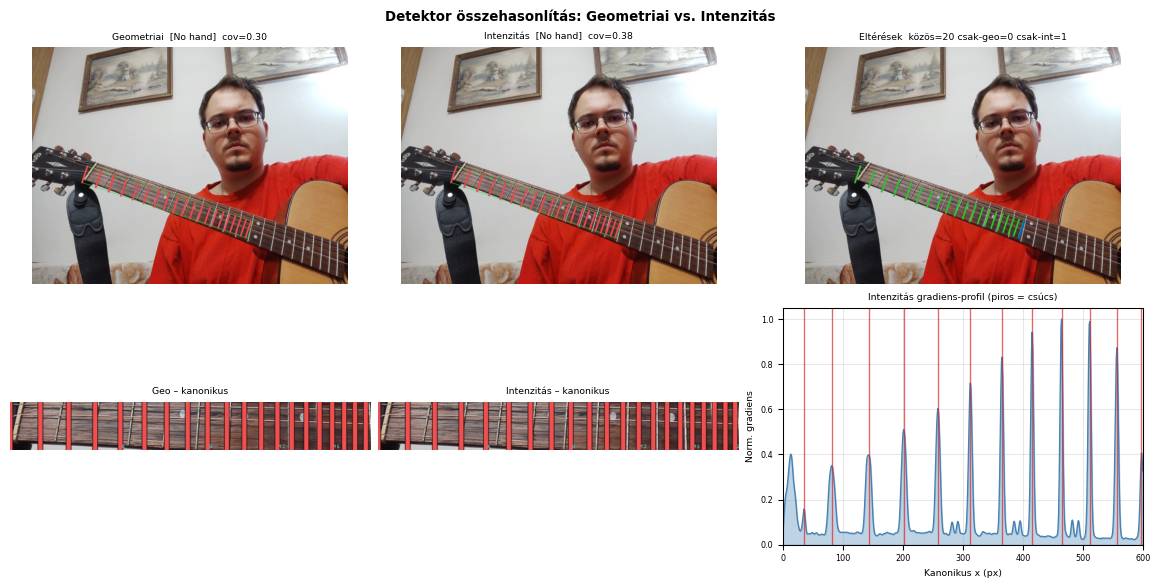

Mentve: ../output/06_comparison_dashboard/detailed_03_IMG_20251102_023831.jpg.png


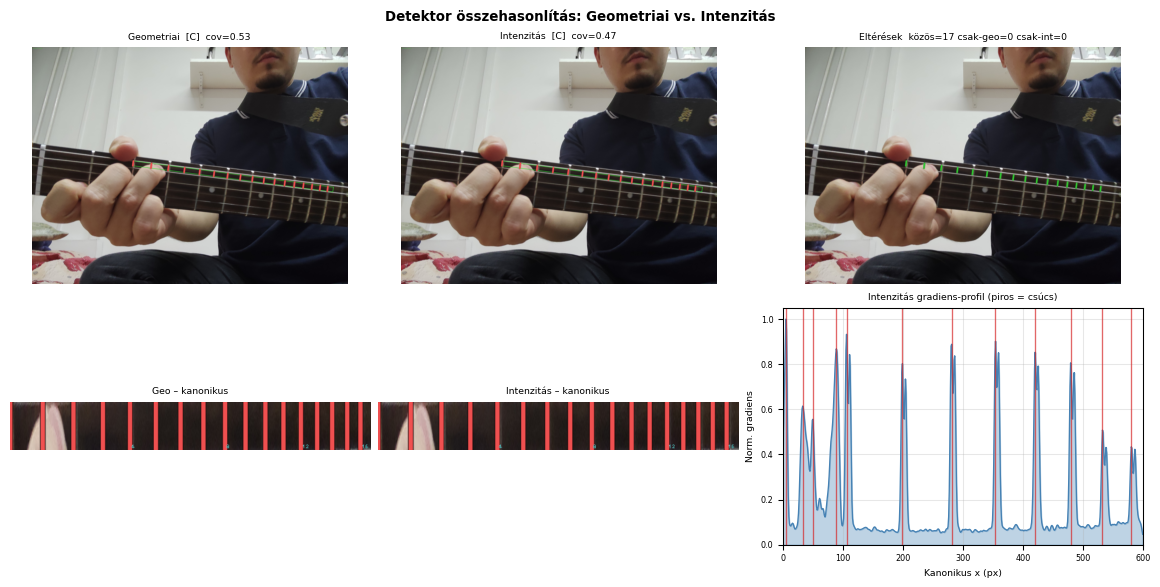

Mentve: ../output/06_comparison_dashboard/detailed_04_1762212395050.jpg.png


In [6]:
for i, (r_geo, r_int) in enumerate(pipeline_pairs):
    if not (r_geo.get('ok') or r_int.get('ok')):
        print(f"[{i}] Mindkét detektor sikertelen – részletes nézet kihagyva.")
        continue

    img_path = r_geo.get('path') or r_int.get('path')
    image    = cv2.imread(str(img_path))
    if image is None:
        continue

    fname     = r_geo.get('fname', r_geo.get('filename', Path(img_path).name))
    save_path = OUTPUT_DIR / f'detailed_{i:02d}_{fname}.png'

    fig = viz.draw_detector_comparison(
        image,
        result_geo=r_geo,
        result_int=r_int,
        figsize=(19, 10),
        save_path=save_path,
    )
    print(f'Mentve: {save_path}')
    plt.close(fig)

## 6. Összefoglaló táblázat

A JOURNAL.md-ben látott formátumban.

In [7]:
rows = []
for r_geo, r_int in pipeline_pairs:
    geo_cov  = r_geo.get('fit', {}).get('coverage_ratio', 0.0) or 0.0
    int_cov  = r_int.get('fit', {}).get('coverage_ratio', 0.0) or 0.0
    geo_n    = len(r_geo.get('fret_xs_raw') or [])
    int_n    = len(r_int.get('fret_xs_raw') or [])
    geo_sc   = r_geo.get('fit', {}).get('score', 0.0) or 0.
    int_sc   = r_int.get('fit', {}).get('score', 0.0) or 0.0
    rows.append({
        'Fájl':    r_geo.get('fname', r_geo.get('filename', '?')),
        'Cls':     r_geo.get('class', '?'),
        'geo_ok':  '✓' if r_geo['ok'] else '✗',
        'int_ok':  '✓' if r_int['ok'] else '✗',
        'geo_cov': f'{geo_cov:.3f}',
        'int_cov': f'{int_cov:.3f}',
        'geo_n':   geo_n,
        'int_n':   int_n,
        'geo_sc':  f'{geo_sc:.2f}',
        'int_sc':  f'{int_sc:.2f}',
    })

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

# Aggregált statisztikák
ok_geo = sum(1 for r, _ in pipeline_pairs if r['ok'])
ok_int = sum(1 for _, r in pipeline_pairs if r['ok'])
cov_geo_avg = np.mean([r.get('fit', {}).get('coverage_ratio', 0.0) or 0.0 for r, _ in pipeline_pairs])
cov_int_avg = np.mean([r.get('fit', {}).get('coverage_ratio', 0.0) or 0.0 for _, r in pipeline_pairs])

print(f"\nÖsszesítés ({len(pipeline_pairs)} kép):")
print(f"  geo ok-rate:  {ok_geo}/{len(pipeline_pairs)} = {ok_geo/len(pipeline_pairs)*100:.1f}%")
print(f"  int ok-rate:  {ok_int}/{len(pipeline_pairs)} = {ok_int/len(pipeline_pairs)*100:.1f}%")
print(f"  geo avg cov:  {cov_geo_avg:.3f}")
print(f"  int avg cov:  {cov_int_avg:.3f}")

                   Fájl     Cls geo_ok int_ok geo_cov int_cov  geo_n  int_n geo_sc int_sc
      1762212364116.jpg       B      ✓      ✓   0.833   0.833     10     12   0.83   0.69
IMG_20251102_023927.jpg       F      ✓      ✓   0.727   0.545     10     20   0.73   0.55
      1762212326260.jpg       A      ✓      ✓   0.476   0.600     12     19   0.48   0.60
IMG_20251102_023831.jpg No hand      ✓      ✓   0.300   0.381      7     12   0.30   0.38
      1762212395050.jpg       C      ✓      ✓   0.529   0.471     10     12   0.48   0.47

Összesítés (5 kép):
  geo ok-rate:  5/5 = 100.0%
  int ok-rate:  5/5 = 100.0%
  geo avg cov:  0.573
  int avg cov:  0.566
